In [1]:
import glob

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn.cluster as cluster
import umap
from Bio.PDB import PDBParser
from Bio.PDB.Polypeptide import PPBuilder
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler
from scipy.stats import pearsonr

/home/kunzj/venv/test/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


the sequences and pdb files were manually copied here in the data folder from the bindcraft iterations

In [2]:
def get_whole_seq(binder_idx,iteration=''):
    # Load the PDB file
    parser = PDBParser(QUIET=True)
    ppb = PPBuilder()
    pattern = f"../../data/sequences/{iteration}{str(binder_idx)}_BAX_1F16_*.pdb"
    file = glob.glob(pattern)
    structure = parser.get_structure("protein", file[0])
    chains = ppb.build_peptides(structure)
    seq_prot = chains[0].get_sequence()
    seq_pept = chains[1].get_sequence()
    return seq_prot, seq_pept

### data retrieval

In [19]:
df = pd.read_csv("../../data/mmpbsa/md_data_all_binders_raw.csv", index_col=0)

df.set_index("Binder_ID", inplace=True)
features = ["energies", "rmsd", "bsa", "hbond", "sbridge"]
n_clusters = 4
df["seq_prot"] = str
df["seq_pept"] = str
for idx in df.index:
    seq_prot, seq_pept = get_whole_seq(idx)
    df.loc[idx, "seq_prot"] = str(seq_prot)
    df.loc[idx, "seq_pept"] = str(seq_pept)
df_raw = df.copy()

In [20]:
# features which are already +1 as best value
for col in ["sbridge", "hbond"]:
    scaler = MinMaxScaler(feature_range=(-1, 1))
    df[col] = scaler.fit_transform(df[[col]])

# features which need to be inverted so that best value is at +1
for col in ["energies", "bsa", "rmsd"]:
    scaler = MinMaxScaler(feature_range=(-1, 1))
    df[col] = -scaler.fit_transform(df[[col]])

### own score creation

In [21]:
print("Pearson correlation coefficients:")
print("----------------------------------")
for val in ["hbond", "rmsd", "sbridge", "bsa"]:
    r, p = pearsonr(list(df["energies"]), list(df[val]))
    print(f"{val} ~ r={r:.3f}, p={p:.2e}")
    print("")
print("----------------------------------")
weights = {
    "energies": 2,
    "hbond": 1.59,
    "rmsd": 1.347,
    "sbridge": 1.166,
    "bsa": 0.9,
}
print("Chosen Weights for final score calculation:")
print("----------------------------------")
for k, v in weights.items():
    print(f"{k}: {v}")
    print("")
print("----------------------------------")


Pearson correlation coefficients:
----------------------------------
hbond ~ r=0.590, p=6.51e-11

rmsd ~ r=0.347, p=3.60e-04

sbridge ~ r=0.166, p=9.58e-02

bsa ~ r=-0.100, p=3.15e-01

----------------------------------
Chosen Weights for final score calculation:
----------------------------------
energies: 2

hbond: 1.59

rmsd: 1.347

sbridge: 1.166

bsa: 0.9

----------------------------------


In [22]:
df["final_score"] = (
    df["energies"] * weights["energies"]
    + df["rmsd"] * weights["rmsd"]
    + df["bsa"] * weights["bsa"]
    + df["hbond"] * weights["hbond"]
    + df["sbridge"] * weights["sbridge"]
)
scaler = MinMaxScaler(feature_range=(-1, 1))
df["final_score"] = scaler.fit_transform(df[["final_score"]])
# df[["final_score", "seq_prot", "seq_pept"]].to_csv(
#     "../../data/mmpbsa/finished_data_cosine_sim.csv"
# )

### dataset creation for second iteration

In [4]:
df_first_iteration = pd.read_csv("../../data/mmpbsa/md_data_all_binders_raw.csv", index_col=0)

df_first_iteration.set_index("Binder_ID", inplace=True)
features = ["energies", "rmsd", "bsa", "hbond", "sbridge"]

df_first_iteration["seq_prot"] = str
df_first_iteration["seq_pept"] = str
for idx in df_first_iteration.index:
    seq_prot, seq_pept = get_whole_seq(idx,iteration='first/')
    df_first_iteration.loc[idx, "seq_prot"] = str(seq_prot)
    df_first_iteration.loc[idx, "seq_pept"] = str(seq_pept)


df_second_iteration = pd.read_csv("../../data/mmpbsa/second_iteration/md_data_all_binders_raw_second_iteration.csv", index_col=0)

df_second_iteration.set_index("Binder_ID", inplace=True)
features = ["energies", "rmsd", "bsa", "hbond", "sbridge"]

df_second_iteration["seq_prot"] = str
df_second_iteration["seq_pept"] = str
for idx in df_second_iteration.index:
    seq_prot, seq_pept = get_whole_seq(idx,iteration='second/')
    df_second_iteration.loc[idx, "seq_prot"] = str(seq_prot)
    df_second_iteration.loc[idx, "seq_pept"] = str(seq_pept)
    

df = pd.concat([df_first_iteration, df_second_iteration])

### normal procedure ###

# features which are already +1 as best value
for col in ["sbridge", "hbond"]:
    scaler = MinMaxScaler(feature_range=(-1, 1))
    df[col] = scaler.fit_transform(df[[col]])

# features which need to be inverted so that best value is at +1
for col in ["energies", "bsa", "rmsd"]:
    scaler = MinMaxScaler(feature_range=(-1, 1))
    df[col] = -scaler.fit_transform(df[[col]])
    
print("Pearson correlation coefficients:")
print("----------------------------------")
for val in ["hbond", "rmsd", "sbridge", "bsa"]:
    r, p = pearsonr(list(df["energies"]), list(df[val]))
    print(f"{val} ~ r={r:.3f}, p={p:.2e}")
    print("")
print("----------------------------------")


Pearson correlation coefficients:
----------------------------------
hbond ~ r=0.552, p=1.22e-17

rmsd ~ r=0.275, p=6.76e-05

sbridge ~ r=0.117, p=9.53e-02

bsa ~ r=-0.064, p=3.65e-01

----------------------------------


In [5]:
weights = {
    "energies": 2,
    "hbond": 1.55,
    "rmsd": 1.28,
    "sbridge": 1.12,
    "bsa": 0.94,
}
print("Chosen Weights for final score calculation:")
print("----------------------------------")
for k, v in weights.items():
    print(f"{k}: {v}")
    print("")
print("----------------------------------")


df["final_score"] = (
    df["energies"] * weights["energies"]
    + df["rmsd"] * weights["rmsd"]
    + df["bsa"] * weights["bsa"]
    + df["hbond"] * weights["hbond"]
    + df["sbridge"] * weights["sbridge"]
)
scaler = MinMaxScaler(feature_range=(-1, 1))
df["final_score"] = scaler.fit_transform(df[["final_score"]])
df[["final_score", "seq_prot", "seq_pept"]].to_csv(
    "../../data/mmpbsa/second_iteration/finished_data_cosine_sim_second_iteration.csv"
)

Chosen Weights for final score calculation:
----------------------------------
energies: 2

hbond: 1.55

rmsd: 1.28

sbridge: 1.12

bsa: 0.94

----------------------------------


## not relevant anymore after this

!!! \
actually everything all of this is useless as this introduces data leakage \
the only thing actually relevant is the whole mmpbsa dataset and the ppi dataset to show that our model works fine \
!!!

### pca

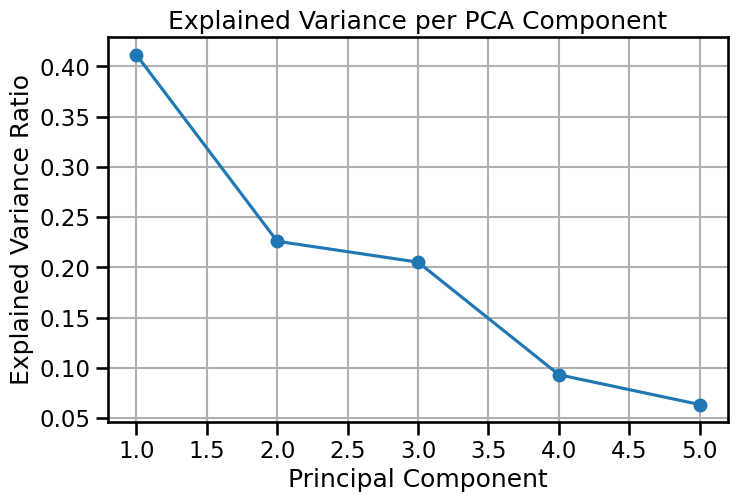

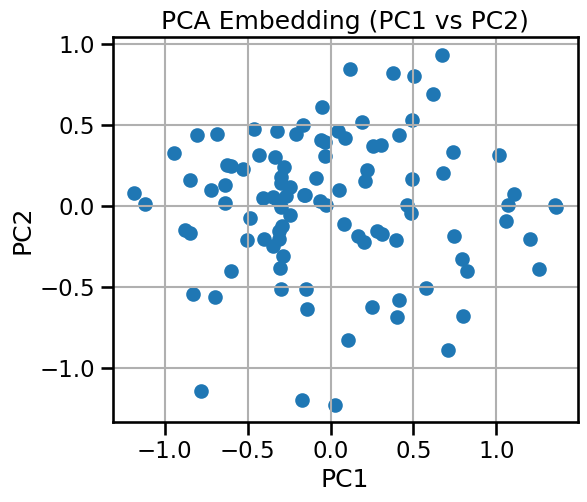


PCA Loadings:
               PC1       PC2       PC3       PC4       PC5
sbridge   0.444263  0.532069  0.705989 -0.107841 -0.097383
hbond     0.649411 -0.042843 -0.248447  0.701437  0.150632
energies  0.579500 -0.207214 -0.351858 -0.591211 -0.384588
bsa      -0.112753  0.819544 -0.558611 -0.032622 -0.050244
rmsd      0.179897  0.021849 -0.063281 -0.381787  0.904098

Top contributing feature per principal component:
PC1      hbond
PC2        bsa
PC3    sbridge
PC4      hbond
PC5       rmsd
dtype: object


In [45]:
# -------------------------
# Assume df already exists
# -------------------------

# 1. Standardize the features
X = df[["sbridge", "hbond", "energies", "bsa", "rmsd"]].values


# 2. Run PCA
pca = PCA(5)
X_pca = pca.fit_transform(X)

# 3. Explained variance per component
explained_variance = pca.explained_variance_ratio_
components = np.arange(1, len(explained_variance) + 1)

plt.figure(figsize=(8, 5))
plt.plot(components, explained_variance, marker="o")
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Explained Variance per PCA Component")
plt.grid(True)
plt.show()

# 4. PCA embedding (PC1 vs PC2)
plt.figure(figsize=(6, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1])
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Embedding (PC1 vs PC2)")
plt.grid(True)
plt.show()

# 5. Get PCA component loadings
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f"PC{i + 1}" for i in range(pca.n_components_)],
    index=df[["sbridge", "hbond", "energies", "bsa", "rmsd"]].columns,
)

print("\nPCA Loadings:")
print(loadings)

# 6. Identify the dominant features per component
top_features = loadings.abs().idxmax()
print("\nTop contributing feature per principal component:")
print(top_features)

### three way split for testing

In [68]:
df_train = df_raw.sample(frac=0.6, random_state=42)
df_validation_test = df_raw.drop(df_train.index)
df_validation = df_validation_test.sample(frac=0.2, random_state=42)
df_test = df_validation_test.drop(df_validation.index)
df_split = {"train": df_train, "validation": df_validation, "test": df_test}

for idx in df_split.keys():
    # features which are already +1 as best value
    for col in ["sbridge", "hbond"]:
        scaler = MinMaxScaler(feature_range=(-1, 1))
        df_split[idx][col] = scaler.fit_transform(df_split[idx][[col]])

    # features which need to be inverted so that best value is at +1
    for col in ["energies", "bsa", "rmsd"]:
        scaler = MinMaxScaler(feature_range=(-1, 1))
        df_split[idx][col] = -scaler.fit_transform(df_split[idx][[col]])

    df_split[idx]["final_score"] = (
        df_split[idx]["energies"] * weights["energies"]
        + df_split[idx]["rmsd"] * weights["rmsd"]
        + df_split[idx]["bsa"] * weights["bsa"]
        + df_split[idx]["hbond"] * weights["hbond"]
        + df_split[idx]["sbridge"] * weights["sbridge"]
    )
    scaler = MinMaxScaler(feature_range=(-1, 1))
    df_split[idx]["final_score"] = scaler.fit_transform(df_split[idx][["final_score"]])
    df_split[idx][["final_score", "seq_prot", "seq_pept"]].to_csv(
        f"../../data/mmpbsa/three_way_split/finished_data_cosine_sim_{idx}.csv"
    )

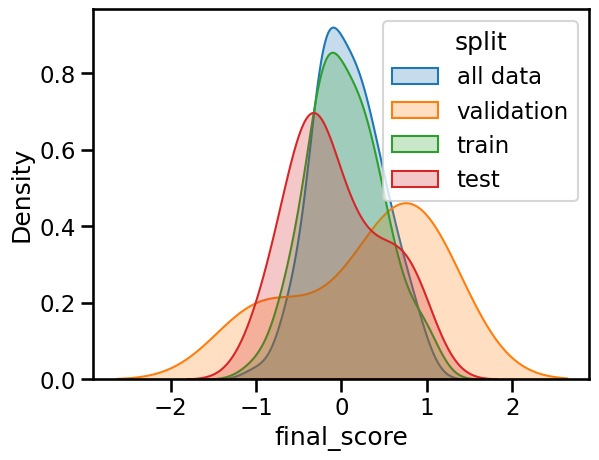

In [70]:
sns.kdeplot(df["final_score"], fill=True, label="all data")
sns.kdeplot(df_validation["final_score"], fill=True, label="validation")
sns.kdeplot(df_train["final_score"], fill=True, label="train")
sns.kdeplot(df_test["final_score"], fill=True, label="test")
plt.legend(title="split")
plt.xlabel("final_score")
plt.ylabel("Density")
plt.show()

### two way split for actual doing stuff

In [76]:
df_train = df_raw.sample(frac=0.8, random_state=42,)
df_validation = df_raw.drop(df_train.index)
df_split = {"train": df_train, "validation": df_validation}

for idx in df_split.keys():
    # features which are already +1 as best value
    for col in ["sbridge", "hbond"]:
        scaler = MinMaxScaler(feature_range=(-1, 1))
        df_split[idx][col] = scaler.fit_transform(df_split[idx][[col]])

    # features which need to be inverted so that best value is at +1
    for col in ["energies", "bsa", "rmsd"]:
        scaler = MinMaxScaler(feature_range=(-1, 1))
        df_split[idx][col] = -scaler.fit_transform(df_split[idx][[col]])

    df_split[idx]["final_score"] = (
        df_split[idx]["energies"] * weights["energies"]
        + df_split[idx]["rmsd"] * weights["rmsd"]
        + df_split[idx]["bsa"] * weights["bsa"]
        + df_split[idx]["hbond"] * weights["hbond"]
        + df_split[idx]["sbridge"] * weights["sbridge"]
    )
    scaler = MinMaxScaler(feature_range=(-1, 1))
    df_split[idx]["final_score"] = scaler.fit_transform(df_split[idx][["final_score"]])
    df_split[idx][["final_score", "seq_prot", "seq_pept"]].to_csv(
        f"../../data/mmpbsa/two_way_split/finished_data_cosine_sim_{idx}.csv"
    )

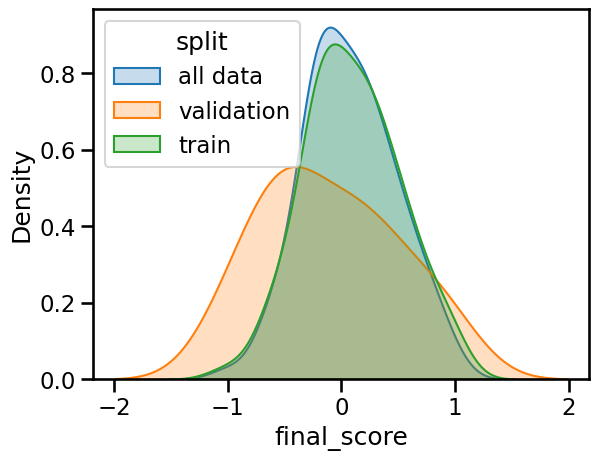

In [ ]:
sns.kdeplot(df["final_score"], fill=True, label="all data")
sns.kdeplot(df_validation["final_score"], fill=True, label="validation")
sns.kdeplot(df_train["final_score"], fill=True, label="train")

plt.legend(title="split")
plt.xlabel("final_score")
plt.ylabel("Density")
plt.show()

## useless

### classification idea - using minmax_scaled data

In [ ]:
kmeans_labels = cluster.KMeans(n_clusters=n_clusters, random_state=1).fit_predict(
    np.array(df[features])
)
embedding = umap.UMAP(random_state=1).fit_transform(np.array(df[features]))

plt.figure(figsize=(15, 5))
scatter = plt.scatter(
    embedding[:, 0],
    embedding[:, 1],
    s=20,
    c=df["energies"].astype(float),
    cmap="Spectral",
)
plt.colorbar(scatter, label="energies")

plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.title("UMAP Embedding ")
plt.tight_layout()
plt.figure(figsize=(15, 5))
scatter = plt.scatter(
    embedding[:, 0],
    embedding[:, 1],
    s=20,
    c=kmeans_labels.astype(float),
    cmap="Spectral",
)
plt.colorbar(scatter, label="Labels")

plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.title("UMAP Embedding ")
plt.tight_layout()

In [ ]:
df["labels"] = kmeans_labels
# Calculate mean energies for each label
mean_energies = [df[df["labels"] == i]["energies"].mean() for i in range(5)]

# Create a mapping from old labels to new labels (sorted by mean energy)
label_mapping = {
    old_label: new_label
    for new_label, old_label in enumerate(
        sorted(range(5), key=lambda i: mean_energies[i])
    )
}

# Apply the mapping to relabel
df["labels"] = df["labels"].map(label_mapping)
kmeans_labels = df["labels"].values

print("binder classes mean:")
print(f"no binder: {df[df['labels'] == 0]['energies'].mean()}")
print(f"less worse binder:{df[df['labels'] == 1]['energies'].mean()}")
print(f"mid binder:{df[df['labels'] == 2]['energies'].mean()}")
print(f"semi good binder:{df[df['labels'] == 3]['energies'].mean()}")
print(f"best binder:{df[df['labels'] == 4]['energies'].mean()}")

In [ ]:
labels = sorted(df["labels"].unique())
n_labels = len(labels)
n_features = len(features)
feature_colors = sns.color_palette("Set2", n_features)

fig, axes = plt.subplots(
    n_labels,
    n_features,
    figsize=(4 * n_features, 3 * n_labels),
    constrained_layout=True,
    sharex=True,
)

for i, lab in enumerate(labels):
    subset = df[df["labels"] == lab]
    for j, feat in enumerate(features):
        ax = axes[i, j]
        sns.kdeplot(subset[feat], ax=ax, color=feature_colors[j])
        if j == 0:
            ax.set_ylabel(f"Label {lab}\n(n={len(subset)})")
        else:
            ax.set_ylabel("")
        if i == n_labels - 1:
            ax.set_xlabel(feat)
        else:
            ax.set_xlabel("")

plt.tight_layout()
plt.show()

In [ ]:
labels = sorted(df["labels"].unique())
n_features = len(features)

fig, axes = plt.subplots(
    1, n_features, figsize=(4 * n_features, 4), constrained_layout=False
)

for j, feat in enumerate(features):
    ax = axes[j]
    for lab in labels:
        subset = df[df["labels"] == lab]
        sns.kdeplot(subset[feat], ax=ax, label=f"Label {lab}")
    ax.set_title(feat)
    ax.set_xlabel("")
    ax.set_ylabel("Density")

# Place a wide legend below the figure
handles, legend_labels = axes[0].get_legend_handles_labels()
fig.subplots_adjust(bottom=0.2)
fig.legend(
    handles,
    legend_labels,
    loc="lower center",
    ncol=len(labels),
    title="Label",
    frameon=False,
)

plt.show()


In [ ]:
from sklearn.linear_model import LinearRegression

# Prepare features (X) and target (y)
X = df[features]
Y = df["labels"]

# Create and fit the linear regression model
model = LinearRegression()
model.fit(X, Y)

print(f"features: {features}")
print("Linear Regression Model:")
print(f"Coefficients: {model.coef_}")
print(f"Intercept: {model.intercept_}")
print(f"R² Score: {model.score(X, Y)}")

In [ ]:
model.intercept_ + (X * model.coef_).sum(axis=1)

In [ ]:
df["final_score"] = model.intercept_ + (X * model.coef_).sum(axis=1)
df.index = df.index.astype(str)

In [ ]:
df

### regression idea with pca

In [ ]:
# Prepare features (X) and target (y)
X = df[["energies", "rmsd", "bsa", "hbond", "sbridge"]]
Y = df["labels"]

# Hold out a certain percentile of each label for testing
test_percentile = 20  # Hold out 20% for testing

X_train, X_test = [], []
Y_train, Y_test = [], []

for label in df["labels"].unique():
    label_mask = df["labels"] == label
    label_indices = df[label_mask].index

    n_test = max(1, int(len(label_indices) * test_percentile / 100))
    test_indices = np.random.choice(label_indices, size=n_test, replace=False)
    train_indices = label_indices.difference(test_indices)

    X_train.append(X.loc[train_indices])
    X_test.append(X.loc[test_indices])
    Y_train.append(Y.loc[train_indices])
    Y_test.append(Y.loc[test_indices])

X_train = pd.concat(X_train)
X_test = pd.concat(X_test)
Y_train = pd.concat(Y_train)
Y_test = pd.concat(Y_test)

print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")
print(f"\nTraining set label distribution:\n{Y_train.value_counts().sort_index()}")
print(f"\nTest set label distribution:\n{Y_test.value_counts().sort_index()}")


# Create and fit the linear regression model
model = LinearRegression()
model.fit(X_train, Y_train)
pred_Y = model.predict(X_test)


print("Linear Regression Model:")
print(f"Coefficients: {model.coef_}")
print(f"Intercept: {model.intercept_}")
print(f"R² Score: {model.score(X_test, Y_test)}")

In [ ]:
# -------------------------
# Assume df already exists
# -------------------------

# 1. Standardize the features
X = df[["sbridge", "hbond", "energies", "bsa", "rmsd"]]

# 2. Run PCA
pca = PCA(n_components=5)
X_pca = pca.fit_transform(X)

# 3. Explained variance per component
explained_variance = pca.explained_variance_ratio_
components = np.arange(1, len(explained_variance) + 1)

plt.figure(figsize=(8, 5))
plt.plot(components, explained_variance, marker="o")
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Explained Variance per PCA Component")
plt.grid(True)
plt.show()

# 4. PCA embedding (PC1 vs PC2)
plt.figure(figsize=(6, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1])
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Embedding (PC1 vs PC2)")
plt.grid(True)
plt.show()

# 5. Get PCA component loadings
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f"PC{i + 1}" for i in range(pca.n_components_)],
    index=df.columns[:-1],
)

print("\nPCA Loadings:")
print(loadings)

# 6. Identify the dominant features per component
top_features = loadings.abs().idxmax()
print("\nTop contributing feature per principal component:")
print(top_features)

In [ ]:
pca.components[0]